# Loading&EDA


In [1]:
import os

# Set your W&B token
#os.environ["WANDB_API_KEY"]="???"
# os.environ["HF_HOME"] = "/mnt/disks/ai-training/hf_cache"
# os.environ["HF_HUB_CACHE"] = "/mnt/disks/ai-training/hf_cache/hub"
# os.environ["TRANSFORMERS_CACHE"] = "/mnt/disks/ai-training/hf_cache/transformers"

import torch
import torchvision
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import torchvision.transforms as T
import numpy as np
import cv2
import graphviz
import pytorch_lightning as pl
!pip install segmentation_models_pytorch
import segmentation_models_pytorch as smp

import torchmetrics
import wandb
import timm
import albumentations as A
import pandas as pd
!pip install ttach
import ttach as tta
import math
import xml.etree.ElementTree as ET 
from tqdm import tqdm
from glob import glob

from albumentations.pytorch import ToTensorV2
!pip install torchview
from torchview import draw_graph
from scipy.ndimage import gaussian_laplace, binary_erosion, distance_transform_edt
from pytorch_lightning.loggers import WandbLogger
from pytorch_lightning.callbacks import ModelCheckpoint, LearningRateMonitor
from PIL import Image, ImageFile
#!pip install iterstrat
# iterstrat.ml_stratifiers import MultilabelStratifiedKFold
from sklearn.metrics import f1_score
from sklearn.model_selection import StratifiedKFold
from scipy.special import softmax
from matplotlib.patches import Rectangle
!pip install torch
from torchmetrics.segmentation import DiceScore, MeanIoU

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 3.8 MB/s eta 0:00:0000:01


In [2]:
VOC_CLASSES = {
    0: "background",
    1: "aeroplane",
    2: "bicycle",
    3: "bird",
    4: "boat",
    5: "bottle",
    6: "bus",
    7: "car",
    8: "cat",
    9: "chair",
    10: "cow",
    11: "diningtable",
    12: "dog",
    13: "horse",
    14: "motorbike",
    15: "person",
    16: "pottedplant",
    17: "sheep",
    18: "sofa",
    19: "train",
    20: "tvmonitor",
    255: "ignore",
}
VOC_CLASSES_INVERSE = {v:k for k,v in VOC_CLASSES.items()}

VOC_COLORMAP = np.array([
    [0, 0, 0],
    [128, 0, 0],
    [0, 128, 0],
    [128, 128, 0],
    [0, 0, 128],
    [128, 0, 128],
    [0, 128, 128],
    [128, 128, 128],
    [64, 0, 0],
    [192, 0, 0],
    [64, 128, 0],
    [192, 128, 0],
    [64, 0, 128],
    [192, 0, 128],
    [64, 128, 128],
    [192, 128, 128],
    [0, 64, 0],
    [128, 64, 0],
    [0, 192, 0],
    [128, 192, 0],
    [0, 64, 128],
], dtype=np.uint8)

In [3]:
IMAGE_ROOT=('/kaggle/input/datasets/gopalbhattrai/pascal-voc-2012-dataset/VOC2012_train_val/VOC2012_train_val/JPEGImages')
SEG_ROOT=('/kaggle/input/datasets/gopalbhattrai/pascal-voc-2012-dataset/VOC2012_train_val/VOC2012_train_val/SegmentationClass')


In [4]:
with open("/kaggle/input/datasets/gopalbhattrai/pascal-voc-2012-dataset/VOC2012_train_val/VOC2012_train_val/ImageSets/Segmentation/train.txt", "r") as f:
    train_images=f.readlines()

train_images=[line.strip() for line in train_images]

with open("/kaggle/input/datasets/gopalbhattrai/pascal-voc-2012-dataset/VOC2012_train_val/VOC2012_train_val/ImageSets/Segmentation/val.txt") as f:
    val_images = f.readlines()

val_images=[line.strip() for line in val_images]

print(f"train: {len(train_images)}, val: {len(val_images)}")

train: 1464, val: 1449


In [5]:
import glob 
import pandas as pd
import numpy as np
import os
df = pd.DataFrame({"filename" : [os.path.basename(i) for i in glob.glob('/kaggle/input/datasets/gopalbhattrai/pascal-voc-2012-dataset/VOC2012_train_val/VOC2012_train_val/JPEGImages/*')]})
df['subset']=None
df.loc[df['filename'].apply(lambda x: os.path.splitext(x)[0] in train_images),'subset'] = 'train'
df.loc[df['filename'].apply(lambda x: os.path.splitext(x)[0] in val_images), 'subset'] = 'val'
print(df['subset'].value_counts(dropna=False))
print(df)


subset
None     14212
train     1464
val       1449
Name: count, dtype: int64
              filename subset
0      2007_005304.jpg    val
1      2009_002094.jpg    val
2      2011_006475.jpg   None
3      2011_000611.jpg   None
4      2009_004042.jpg   None
...                ...    ...
17120  2011_003349.jpg   None
17121  2008_004849.jpg   None
17122  2007_003541.jpg  train
17123  2010_001177.jpg  train
17124  2011_004173.jpg   None

[17125 rows x 2 columns]


In [6]:
import xml.etree.ElementTree as ET 
from tqdm import tqdm
import math

def annotation_parser(xml_path):
    tree = ET.parse(xml_path)
    root = tree.getroot()
    data_dict = {
        'filename': [],
        'object_name': [],
        'object_pose': [],
        'object_bbox': []
    }
    filename = root.find("filename").text
    
    for obj_elem in root.findall("object"):
        obj_name = obj_elem.find("name").text
        obj_pose = obj_elem.find("pose").text
        bbox_elem = obj_elem.find("bndbox")
        xmin = math.floor(float(bbox_elem.find("xmin").text))
        ymin = math.floor(float(bbox_elem.find("ymin").text))
        xmax = math.ceil(float(bbox_elem.find("xmax").text))
        ymax = math.ceil(float(bbox_elem.find("ymax").text))
    
        data_dict['filename'].append(filename)
        data_dict['object_name'].append(obj_name)
        data_dict['object_pose'].append(obj_pose)
        data_dict['object_bbox'].append([xmin, ymin, xmax, ymax])

    return data_dict

df_annot = pd.concat([pd.DataFrame(annotation_parser(i)) for i in tqdm(glob.glob('/kaggle/input/datasets/gopalbhattrai/pascal-voc-2012-dataset/VOC2012_train_val/VOC2012_train_val/Annotations/*'))],
axis=0).reset_index(drop=True)

100%|██████████| 17125/17125 [03:10<00:00, 90.10it/s]


In [7]:
df_objects = df_annot.groupby("filename")["object_name"].apply(list)
df_objects

filename
2007_000027.jpg                                  [person]
2007_000032.jpg    [aeroplane, aeroplane, person, person]
2007_000033.jpg         [aeroplane, aeroplane, aeroplane]
2007_000039.jpg                               [tvmonitor]
2007_000042.jpg                            [train, train]
                                    ...                  
2012_004326.jpg                                  [person]
2012_004328.jpg                          [person, person]
2012_004329.jpg                                  [person]
2012_004330.jpg                                  [person]
2012_004331.jpg                                  [person]
Name: object_name, Length: 17125, dtype: object

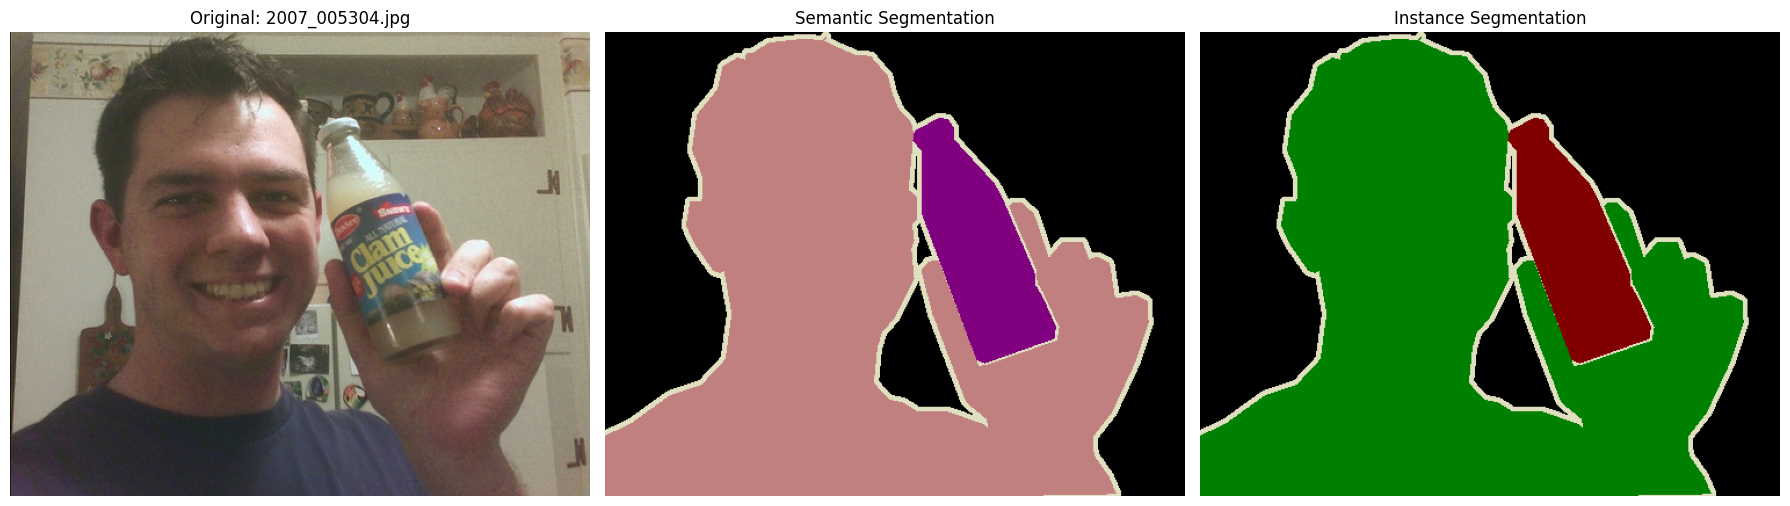

In [8]:
from PIL import Image
import matplotlib.pyplot as plt

import os
import matplotlib.pyplot as plt
from PIL import Image


INST_ROOT = SEG_ROOT.replace('SegmentationClass', 'SegmentationObject')

plt.figure(figsize=(18, 6))

i = 0 
fname = df['filename'][i]
mask_fname = fname.replace('.jpg', '.png')

plt.subplot(1, 3, 1)
img = Image.open(os.path.join(IMAGE_ROOT, fname))
plt.imshow(img)
plt.title(f"Original: {fname}")
plt.axis('off')

plt.subplot(1, 3, 2)
segm_class = Image.open(os.path.join(SEG_ROOT, mask_fname))
plt.imshow(segm_class)
plt.title("Semantic Segmentation")
plt.axis('off')

plt.subplot(1, 3, 3)
segm_inst = Image.open(os.path.join(INST_ROOT, mask_fname))
plt.imshow(segm_inst)
plt.title("Instance Segmentation")
plt.axis('off')

plt.tight_layout()
plt.show()

In [9]:
df_objects = df_objects[df_objects.index.isin(df.loc[~df["subset"].isna(), "filename"])]

Classes present in mask: ['motorbike']


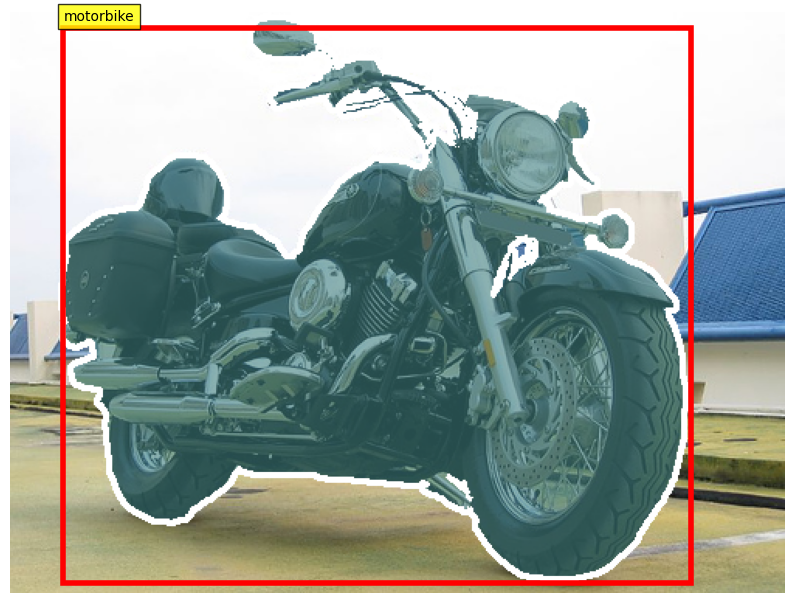

In [10]:
from matplotlib.patches import Rectangle
def visualize_voc(
    image_path,
    mask_path,
    object_classes,
    object_bboxes,
    alpha=0.6,
    figsize=(10, 8),
):
    
    image = np.array(Image.open(image_path).convert("RGB"))
    mask = np.array(Image.open(mask_path))

    color_mask = np.zeros((*mask.shape, 3), dtype=np.uint8)

    valid_classes = (mask > 0) & (mask < 255)

    color_mask[valid_classes] = VOC_COLORMAP[mask[valid_classes]]

    border_pixels = mask == 255
    color_mask[border_pixels] = [255, 255, 255]  

    overlay = image.copy().astype(float)

    overlay[valid_classes] = (
        (1 - alpha) * overlay[valid_classes] +
        alpha * color_mask[valid_classes]
    )

    overlay[border_pixels] = [255, 255, 255]

    overlay = overlay.astype(np.uint8)

    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(overlay)

    for cls, bbox in zip(object_classes, object_bboxes):

        xmin, ymin, xmax, ymax = bbox

        rect = Rectangle(
            (xmin, ymin),
            xmax - xmin,
            ymax - ymin,
            fill=False,
            linewidth=4,
            color="red"
        )

        ax.add_patch(rect)

        ax.text(
            xmin,
            max(0, ymin - 5),
            cls,
            color="black",
            bbox=dict(facecolor="yellow", alpha=0.8),
            fontsize=10,
        )

    ax.axis("off")

    present_classes = sorted(
        [c for c in np.unique(mask) if c not in [0, 255]]
    )

    present_names = [VOC_CLASSES[c] for c in present_classes]

    print("Classes present in mask:", present_names)

    plt.show()

rand_filename = np.random.choice(df_objects.index)

visualize_voc(
    image_path=os.path.join(IMAGE_ROOT, rand_filename),
    mask_path=os.path.join(SEG_ROOT, rand_filename.replace(".jpg", ".png")),
    object_classes=df_annot.loc[df_annot["filename"] == rand_filename, "object_name"].to_list(),
    object_bboxes=df_annot.loc[df_annot["filename"] == rand_filename, "object_bbox"].to_list(),
)

In [11]:
def get_size(fname):
    with Image.open(fname) as img:
        return img.size  

df_trainval = df[~df["subset"].isna()].reset_index(drop=True)
df_trainval = df_trainval.merge(df_objects.reset_index(), on="filename")

df_trainval[["width", "height"]] = df_trainval["filename"].apply(
    lambda x: get_size(os.path.join(IMAGE_ROOT, x))
).apply(pd.Series)

df_trainval

KeyboardInterrupt: 

# Metrics

In [16]:
def _to_bool_mask(mask: np.ndarray, threshold: float = 0.5) -> np.ndarray:
    mask = np.asarray(mask)

    if mask.dtype == bool:
        return mask

    if np.issubdtype(mask.dtype, np.floating):
        return mask >= threshold

    return mask > 0


def dice_score(gt: np.ndarray, pred: np.ndarray, threshold: float = 0.5, eps: float = 1e-8) -> float:

    gt = _to_bool_mask(gt, threshold)
    pred = _to_bool_mask(pred, threshold)

    intersection = np.logical_and(gt, pred).sum()
    gt_sum = gt.sum()
    pred_sum = pred.sum()

    if gt_sum == 0 and pred_sum == 0:
        return 1.0

    return (2.0 * intersection + eps) / (gt_sum + pred_sum + eps)


def iou_score(gt: np.ndarray, pred: np.ndarray, threshold: float = 0.5, eps: float = 1e-8) -> float:

    gt = _to_bool_mask(gt, threshold)
    pred = _to_bool_mask(pred, threshold)

    intersection = np.logical_and(gt, pred).sum()
    union = np.logical_or(gt, pred).sum()

    if union == 0:
        return 1.0

    return (intersection + eps) / (union + eps)


def _extract_boundary(mask: np.ndarray) -> np.ndarray:

    if not mask.any():
        return np.zeros_like(mask, dtype=bool)

    eroded = binary_erosion(mask)
    boundary = np.logical_and(mask, np.logical_not(eroded))
    return boundary


def hausdorff_distance(gt: np.ndarray, pred: np.ndarray, threshold: float = 0.5) -> float:

    gt = _to_bool_mask(gt, threshold)
    pred = _to_bool_mask(pred, threshold)

    if not gt.any() and not pred.any():
        return 0.0
    if not gt.any() or not pred.any():
        return float("inf")

    gt_boundary = _extract_boundary(gt)
    pred_boundary = _extract_boundary(pred)

    if not gt_boundary.any() and not pred_boundary.any():
        return 0.0
    if not gt_boundary.any() or not pred_boundary.any():
        return float("inf")

    dt_pred = distance_transform_edt(~pred_boundary)
    dt_gt = distance_transform_edt(~gt_boundary)

    gt_to_pred = dt_pred[gt_boundary].max()
    pred_to_gt = dt_gt[pred_boundary].max()

    return float(max(gt_to_pred, pred_to_gt))

def segmentation_metrics(gt: np.ndarray, pred: np.ndarray, threshold: float = 0.5) -> dict:
    return {
        "dice": dice_score(gt, pred, threshold=threshold),
        "iou": iou_score(gt, pred, threshold=threshold),
        "hausdorff": hausdorff_distance(gt, pred, threshold=threshold),
    }

In [17]:
class SegmentDataset(torch.utils.data.Dataset):
    def __init__(self, df, img_dir, mask_dir, file_col='filename', obj_col = 'object_name', transform=None):
        self.df = df
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.file_col = file_col
        self.obj_col = obj_col
        self.transform = transform
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, row[self.file_col])
        mask_path = os.path.join(self.mask_dir, row[self.file_col]).replace('.jpg', '.png')
        img = np.array(Image.open(img_path).convert('RGB'))
        mask = np.array(Image.open(mask_path))

        
        label = row[self.obj_col]
        label_one_hot = torch.zeros((len(VOC_CLASSES_INVERSE) - 2,))
        for cls in label:
            assert cls != "background"
            label_one_hot[VOC_CLASSES_INVERSE[cls] - 1] = 1
        label_one_hot = label_one_hot.float()

        if self.transform:
            image, mask = self.transform(image=img, mask=mask).values()

        if torch.is_tensor(mask):
            mask = mask.long()

        return image, mask, label_one_hot

        

In [18]:
seg_dataset = SegmentDataset(
    df=df_trainval,
    img_dir=IMAGE_ROOT,
    mask_dir=SEG_ROOT,
    transform=A.Compose([
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.ShiftScaleRotate(
            scale_limit=0.5, rotate_limit=0, shift_limit=0.1, p=1, border_mode=0
        ),
        A.PadIfNeeded(min_height=320, min_width=320, p=1),
        A.RandomCrop(height=320, width=320, p=1),
        A.GaussNoise(p=0.2),
        A.Perspective(p=0.5),
        A.OneOf(
            [
                A.CLAHE(p=1),
                A.RandomBrightnessContrast(p=1),
                A.RandomGamma(p=1),
            ],
            p=0.9,
        ),
        A.OneOf(
            [
                A.Sharpen(p=1),
                A.Blur(blur_limit=3, p=1),
                A.MotionBlur(blur_limit=3, p=1),
            ],
            p=0.9,
        ),
        A.OneOf(
            [
                A.RandomBrightnessContrast(p=1),
                A.HueSaturationValue(p=1),
            ],
            p=0.9,
        ),

        # A.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
        # ToTensorV2()
    ])
)

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [19]:
class LitSegmentationDataModule(pl.LightningDataModule):
    def __init__(self, df, img_dir, mask_dir, batch_size=32, num_workers=4, val_tfms=None, train_tfms=None):
        super().__init__()
        self.df = df
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.batch_size = batch_size
        self.num_workers = num_workers

        self.train_tfms = train_tfms
        self.val_tfms = val_tfms
        

    def setup(self, stage=None):
        train_df = self.df[self.df["subset"] == "train"].reset_index(drop=True)
        val_df = self.df[self.df["subset"] == "val"].reset_index(drop=True)

        self.train_ds = SegmentDataset(train_df, self.img_dir, self.mask_dir, transform=self.train_tfms)
        self.val_ds = SegmentDataset(val_df, self.img_dir, self.mask_dir, transform=self.val_tfms)

    def train_dataloader(self):
        return torch.utils.data.DataLoader(
            self.train_ds, batch_size=self.batch_size, 
            shuffle=True, pin_memory=torch.cuda.is_available(),
            num_workers=self.num_workers
        )

    def val_dataloader(self):
        return torch.utils.data.DataLoader(
            self.val_ds, batch_size=self.batch_size, 
            shuffle=False, pin_memory=torch.cuda.is_available(),
            num_workers=self.num_workers
        )

In [20]:
class LitSegmentationModule(pl.LightningModule):
    def __init__(
        self, 
        model_class,
        model_kwargs,
        criterion_inits,
        criterion_kwargs,
        criterion_coefs,
        n_classes,
        initial_lr=1e-3, 
        final_lr=1e-5, 
        T_max=10,
        ignore_index=None
    ):
        super().__init__()
        self.save_hyperparameters()
        self.model = model_class(**model_kwargs)
        self.criterion = nn.ModuleDict({
            name: criterion_inits[name](**criterion_kwargs[name]) for name in criterion_inits.keys()
        })
        self.criterion_coefs = criterion_coefs
        self.train_metrics = torchmetrics.MetricCollection(metrics=[
            DiceScore(
                num_classes=n_classes,
                include_background=False,
                average="micro",
                aggregation_level="samplewise",
                input_format="index"
            ),
            MeanIoU(
                num_classes=n_classes,
                include_background=False,
                per_class=False,
                input_format="index"
            )
        ], compute_groups=False)  
        self.val_metrics = torchmetrics.MetricCollection(metrics=[
            DiceScore(
                num_classes=n_classes,
                include_background=False,
                average="micro",
                aggregation_level="samplewise",
                input_format="index"
            ),
            MeanIoU(
                num_classes=n_classes,
                include_background=False,
                per_class=False,
                input_format="index"
            )
        ], compute_groups=False)
        self.ignore_index = ignore_index

    def forward(self, x):
        return self.model(x)

    def _compute_loss(self, y_pred, y_true):
        losses, loss = {}, 0.0
        for name in self.criterion.keys():
            losses[name] = self.criterion[name](y_pred, y_true)
            loss += self.criterion_coefs[name] * losses[name]
        return losses, loss

    @staticmethod
    def _prepare_image_for_plot(img_tensor: torch.Tensor):
        """
        img_tensor: (C, H, W)
        Returns numpy image in (H, W, C)
        """
        img = img_tensor.detach().float().cpu()

        # If normalized by ImageNet stats, uncomment:
        # mean = torch.tensor([0.485, 0.456, 0.406])[:, None, None]
        # std = torch.tensor([0.229, 0.224, 0.225])[:, None, None]
        # img = img * std + mean

        img = img.permute(1, 2, 0).numpy()

        img_min = img.min()
        img_max = img.max()
        if img_max > img_min:
            img = (img - img_min) / (img_max - img_min)

        return img

    def _log_validation_example(self, img, mask, preds):
        if self.logger is None or not hasattr(self.logger, "experiment"):
            return

        image_np = self._prepare_image_for_plot(img[0])
        gt_np = mask[0].detach().cpu().numpy()
        pred_np = preds[0].detach().cpu().numpy()

        if self.ignore_index is not None:
            gt_vis = gt_np.copy()
            gt_vis[gt_vis == self.ignore_index] = 0
        else:
            gt_vis = gt_np

        fig, axes = plt.subplots(1, 3, figsize=(15, 5))

        axes[0].imshow(image_np)
        axes[0].set_title("Image")
        axes[0].axis("off")

        axes[1].imshow(gt_vis, cmap="tab20", vmin=0, vmax=self.hparams.n_classes - 1)
        axes[1].set_title("GT Mask")
        axes[1].axis("off")

        axes[2].imshow(pred_np, cmap="tab20", vmin=0, vmax=self.hparams.n_classes - 1)
        axes[2].set_title("Pred Mask")
        axes[2].axis("off")

        plt.tight_layout()

        self.logger.experiment.log(
            {
                "val/example_image_gt_pred": wandb.Image(fig),
                "global_step": self.global_step,
                "epoch": self.current_epoch,
            }
        )

        plt.close(fig)

    def training_step(self, batch, batch_idx):
        img, mask, labels = batch 
        logits = self(img)
        losses, loss = self._compute_loss(logits, mask)
        preds = logits.argmax(dim=1)
        mask_copy = mask.clone()
        if self.ignore_index is not None:
            mask_copy[mask_copy == self.ignore_index] = 0
        self.train_metrics.update(preds, mask_copy)
        self.log("train_loss", loss, on_step=True, on_epoch=True, prog_bar=True)
        for sub_loss_name, sub_loss_value in losses.items():
            self.log(f"train_{sub_loss_name}", sub_loss_value, on_step=True, on_epoch=True, prog_bar=True)
        return loss

    def on_train_epoch_end(self):
        self.log_dict(
            {"train_" + k:v for k,v in self.train_metrics.compute().items()},
            on_step=False,
            on_epoch=True,
            prog_bar=True,
            sync_dist=True,
        )
        self.train_metrics.reset()
        pass

    def validation_step(self, batch, batch_idx):
        img, mask, labels = batch
        logits = self(img)
        losses, loss = self._compute_loss(logits, mask)
        preds = logits.argmax(dim=1)
        mask_copy = mask.clone()
        if self.ignore_index is not None:
            mask_copy[mask_copy == self.ignore_index] = 0
        self.val_metrics.update(preds, mask_copy)
        self.log("val_loss", loss, on_step=True, on_epoch=True, prog_bar=True)
        for sub_loss_name, sub_loss_value in losses.items():
            self.log(f"val_{sub_loss_name}", sub_loss_value, on_step=True, on_epoch=True, prog_bar=True)

        if batch_idx == 0:
            self._log_validation_example(img, mask, preds)

    def on_validation_epoch_end(self):
        self.log_dict(
            {"val_" + k:v for k,v in self.val_metrics.compute().items()},
            on_step=False,
            on_epoch=True,
            prog_bar=True,
            sync_dist=True,
        )
        self.val_metrics.reset()
        pass

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(
            self.parameters(), 
            lr=self.hparams.initial_lr
        )
        scheduler = {
            "scheduler": torch.optim.lr_scheduler.CosineAnnealingLR(
                optimizer, 
                T_max=self.hparams.T_max,
                eta_min=self.hparams.final_lr
            ),
            "interval": "step"
        }
        return (
            [optimizer],
            [scheduler]
        )

# CNN (U-NET)

In [21]:
DEVICE = 'cuda'
try:
    N_EPOCHS = 15
    NAME = "smp_unet_resnet34"
    
    datamodule = LitSegmentationDataModule(
        df=df_trainval,
        img_dir=IMAGE_ROOT,
        mask_dir=SEG_ROOT,
        num_workers=12, 
        batch_size=64,
        train_tfms=A.Compose([
            A.HorizontalFlip(p=0.5),
            # A.VerticalFlip(p=0.5),
            A.ShiftScaleRotate(
                scale_limit=0.5, rotate_limit=0, shift_limit=0.1, p=1, border_mode=0
            ),
            A.PadIfNeeded(min_height=320, min_width=320, p=1),
            A.RandomCrop(height=320, width=320, p=1),
            A.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
            ToTensorV2()
        ]),
        val_tfms=A.Compose([
            A.PadIfNeeded(min_height=512, min_width=512, p=1),
            A.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
            ToTensorV2()
        ]),
    )
    datamodule.setup()
    lit_model = LitSegmentationModule(
        model_class=smp.Unet,
        model_kwargs={
            "encoder_name": "resnet34",
            "encoder_weights": "imagenet",
            "in_channels": 3,
            "classes": len(VOC_CLASSES_INVERSE) - 1,
        },
        criterion_inits={ 
            "DiceLoss": smp.losses.DiceLoss,
            "CE": torch.nn.CrossEntropyLoss
        },
        criterion_kwargs={
            "DiceLoss": {"mode":"multiclass", "ignore_index":255},
            "CE": {"ignore_index":255}
        },
        criterion_coefs={
            "DiceLoss": 1.0,
            "CE": 1.0
        },
        initial_lr=1e-3,
        final_lr=1e-5,
        T_max=N_EPOCHS * len(datamodule.train_dataloader()),
        n_classes=len(VOC_CLASSES_INVERSE) - 1,
        ignore_index=255
    )
    wandb_logger = WandbLogger(
        project="CV_Ass3", 
        save_dir=f"logdirs/{NAME}",
        name=NAME
    )
    checkpoint_cb = ModelCheckpoint(
        monitor="val_MeanIoU", mode="max",
        save_top_k=1, filename=NAME + "-{epoch:02d}-{val_MeanIoU:.4f}",
        dirpath=f"logdirs/{NAME}/checkpoints",
        save_weights_only=True,
    )
    lr_monitor = LearningRateMonitor(logging_interval="step")
    trainer = pl.Trainer(
        max_epochs=N_EPOCHS,
        logger=wandb_logger,
        callbacks=[checkpoint_cb, lr_monitor],
        accelerator="auto",
        devices=1 if DEVICE == "cuda" else None,
        precision="16-mixed",
        check_val_every_n_epoch=5,
    )
    
    trainer.fit(lit_model, datamodule=datamodule)
finally:
    wandb.finish()

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 12 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/torchmetrics/utilities/prints.py:43: UserWarning: DiceScore metric currently defaults to `average=micro`, but will change to`average=macro` in the v1.9 release. If you've explicitly set this parameter, you can ignore this warning.
  warnings.warn(*args, **kwargs)
Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
wandb: WARNING The anonymous setting has no effect and will be removed in a future version.
/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my re

  2


...

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will 
create 12 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller 
than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader 
running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/loops/fit_loop.py:317: The number of training batches 
(23) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if
you want to see logs for the training epoch.

`Trainer.fit` stopped: `max_epochs=15` reached.


epoch,▁▁▁▂▂▃▃▃▃▃▃▄▄▅▅▅▅▅▅▆▆▇▇▇▇███
global_step,▁▃▆█
lr-Adam,█▇▅▄▂▁
train_CE_epoch,█▄▄▃▃▃▂▂▂▂▁▁▁▁▁
train_CE_step,█▆▄▄▃▁
train_DiceLoss_epoch,█▇▇▆▅▅▄▃▃▃▂▂▁▁▁
train_DiceLoss_step,█▆▄▁▂▁
train_DiceScore,▁▁▃▃▄▅▅▆▆▇▇▇███
train_MeanIoU,▁▃▄▅▄▅▅▆▆▇▇▇███
train_loss_epoch,█▅▄▃▃▃▃▂▂▂▁▁▁▁▁
+10,...


# SSL (Dino)

## DinoV2SegModel

In [22]:
import math
import timm
import torch
import torch.nn as nn
import torch.nn.functional as F


class DinoV2SegModel(nn.Module):
    def __init__(
        self,
        backbone_name="vit_small_patch14_dinov2.lvd142m",
        num_classes=21,
        pretrained=True,
        freeze_backbone=True,
        decoder_dim=256,
        dropout=0.1,
    ):
        super().__init__()

        self.backbone = timm.create_model(
            backbone_name,
            pretrained=pretrained,
            num_classes=0,
            global_pool=""
        )

        self.embed_dim = self.backbone.num_features
        self.num_classes = num_classes

        if freeze_backbone:
            for p in self.backbone.parameters():
                p.requires_grad = False

        self.decoder = nn.Sequential(
            nn.Conv2d(self.embed_dim, decoder_dim, kernel_size=3, padding=1),
            nn.BatchNorm2d(decoder_dim),
            nn.ReLU(inplace=True),
            nn.Dropout2d(dropout),

            nn.Conv2d(decoder_dim, decoder_dim, kernel_size=3, padding=1),
            nn.BatchNorm2d(decoder_dim),
            nn.ReLU(inplace=True),

            nn.Conv2d(decoder_dim, num_classes, kernel_size=1)
        )

    def forward(self, x):
        B, C, H, W = x.shape

        feats = self.backbone.forward_features(x)

        if isinstance(feats, dict):
            if "x_norm_patchtokens" in feats:
                patch_tokens = feats["x_norm_patchtokens"]
            elif "x_prenorm" in feats:
                patch_tokens = feats["x_prenorm"][:, 1:]
            else:
                raise ValueError(f"Unexpected feature keys: {list(feats.keys())}")
        else:
            if feats.ndim != 3:
                raise ValueError(f"Unexpected feature shape: {feats.shape}")
            patch_tokens = feats[:, 1:]

        B, N, D = patch_tokens.shape

        grid_h = H // 14
        grid_w = W // 14

        if grid_h * grid_w != N:
            side = int(math.sqrt(N))
            if side * side != N:
                raise ValueError(f"Cannot reshape {N} tokens to 2D map")
            grid_h = side
            grid_w = side

        feat_map = patch_tokens.transpose(1, 2).reshape(B, D, grid_h, grid_w)
        logits = self.decoder(feat_map)

        logits = F.interpolate(
            logits,
            size=(H, W),
            mode="bilinear",
            align_corners=False
        )
        return logits

## DINO transforms

In [23]:
DINO_IMG_SIZE = 518

train_tfms_dino = A.Compose([
    A.RandomResizedCrop(
        size=(DINO_IMG_SIZE, DINO_IMG_SIZE),
        scale=(0.7, 1.0),
        ratio=(0.9, 1.1),
        p=1.0
    ),
    A.HorizontalFlip(p=0.5),
    A.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
    ToTensorV2()
])

val_tfms_dino = A.Compose([
    A.Resize(DINO_IMG_SIZE, DINO_IMG_SIZE),
    A.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
    ToTensorV2()
])

## New datamodule саме для DINO

In [24]:
dino_datamodule = LitSegmentationDataModule(
    df=df_trainval,
    img_dir=IMAGE_ROOT,
    mask_dir=SEG_ROOT,
    batch_size=8,
    num_workers=4,
    train_tfms=train_tfms_dino,
    val_tfms=val_tfms_dino,
)

dino_datamodule.setup()

## Швидка shape-перевірка

In [25]:
batch = next(iter(dino_datamodule.train_dataloader()))
imgs, masks, labels = batch

print("imgs:", imgs.shape)
print("masks:", masks.shape)

test_model = DinoV2SegModel(
    backbone_name="vit_small_patch14_dinov2.lvd142m",
    num_classes=len(VOC_CLASSES_INVERSE) - 1,
    pretrained=True,
    freeze_backbone=True,
)

with torch.no_grad():
    out = test_model(imgs[:2])
    print("logits:", out.shape)

imgs: torch.Size([8, 3, 518, 518])
masks: torch.Size([8, 518, 518])


model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

logits: torch.Size([2, 21, 518, 518])


## Запуск DINO

In [29]:
DEVICE = "cuda"
N_EPOCHS = 10
NAME = "dinov2_vits14_frozen_seghead"

try:
    lit_dino_model = LitSegmentationModule(
        model_class=DinoV2SegModel,
        model_kwargs={
            "backbone_name": "vit_small_patch14_dinov2.lvd142m",
            "num_classes": len(VOC_CLASSES_INVERSE) - 1,
            "pretrained": True,
            "freeze_backbone": True,
            "decoder_dim": 256,
            "dropout": 0.1,
        },
        criterion_inits={
            "DiceLoss": smp.losses.DiceLoss,
            "CE": torch.nn.CrossEntropyLoss
        },
        criterion_kwargs={
            "DiceLoss": {"mode": "multiclass", "ignore_index": 255},
            "CE": {"ignore_index": 255}
        },
        criterion_coefs={
            "DiceLoss": 1.0,
            "CE": 1.0
        },
        initial_lr=3e-4,
        final_lr=1e-6,
        T_max=N_EPOCHS * len(dino_datamodule.train_dataloader()),
        n_classes=len(VOC_CLASSES_INVERSE) - 1,
        ignore_index=255
    )

    wandb_logger = WandbLogger(
        project="CV_Ass3",
        save_dir=f"logdirs/{NAME}",
        name=NAME
    )

    checkpoint_cb = ModelCheckpoint(
        monitor="val_MeanIoU",
        mode="max",
        save_top_k=1,
        filename=NAME + "-{epoch:02d}-{val_MeanIoU:.4f}",
        dirpath=f"logdirs/{NAME}/checkpoints",
        save_weights_only=True,
    )

    lr_monitor = LearningRateMonitor(logging_interval="step")

    trainer = pl.Trainer(
        max_epochs=N_EPOCHS,
        logger=wandb_logger,
        callbacks=[checkpoint_cb, lr_monitor],
        accelerator="auto",
        devices=1 if DEVICE == "cuda" else None,
        precision="16-mixed",
        check_val_every_n_epoch=4,
    )

    trainer.fit(lit_dino_model, datamodule=dino_datamodule)

finally:
    wandb.finish()

Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


/usr/local/lib/python3.12/dist-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /kaggle/working/logdirs/dinov2_vits14_frozen_seghead/checkpoints exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model         │ DinoV2SegModel   │ 23.5 M │ train │     0 │
│ 1 │ criterion     │ ModuleDict       │      0 │ train │     0 │
│ 2 │ train_metrics │ MetricCollection │      0 │ train │     0 │
│ 3 │ val_metrics   │ MetricCollection │      0 │ train │     0 │
└───┴───────────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 1.5 M                                                                                            
Non-trainable params: 22.1 M                                                                                       
Total params: 23.5 M                                                                                               
Total estimated model params size (MB): 94                                                                         
Modules in train mode: 295                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

`Trainer.fit` stopped: `max_epochs=10` reached.


epoch,▁▁▁▁▂▂▂▂▃▃▃▃▃▃▃▄▄▄▄▄▅▅▅▆▆▆▆▆▆▆▆▆▆▇▇▇████
global_step,▁▅█
lr-Adam,██████▇▇▇▇▇▆▆▆▅▅▅▅▄▄▄▃▃▃▃▂▂▂▂▂▁▁▁▁▁▁
train_CE_epoch,█▃▂▂▂▁▁▁▁▁
train_CE_step,█▅▃▃▃▂▃▂▃▂▂▄▁▂▁▂▁▂▂▁▂▁▁▁▂▂▁▂▁▁▁▁▂▂▂▁
train_DiceLoss_epoch,█▄▃▂▂▁▁▁▁▁
train_DiceLoss_step,█▇▄▃▆▃▅▆▃▂▅▂▂▅▁▂▂▂▂▁▃▁▄▁▂▁▂▃▃▁▂▂▁▃▃▂
train_DiceScore,▁▆▆▇▇█████
train_MeanIoU,▁▆▇▇▇█████
train_loss_epoch,█▃▂▂▂▁▁▁▁▁
+10,...


# Semi Supervised / Interactive


## Unlabeled data collection

In [30]:
df_unlabeled = df[df["subset"].isna()].reset_index(drop=True)
print(f"Unlabeled images: {len(df_unlabeled)}")
print(f"Train (labeled): {len(df_trainval[df_trainval['subset']=='train'])}")
print(f"Val (labeled): {len(df_trainval[df_trainval['subset']=='val'])}")

sample_unlabeled = df_unlabeled["filename"].iloc[:5].tolist()
for fname in sample_unlabeled:
    mask_path = os.path.join(SEG_ROOT, fname.replace(".jpg", ".png"))
    assert not os.path.exists(mask_path), f"Mask exists for {fname}!"
print("✓ Confirmed: no segmentation masks for unlabeled images")

Unlabeled images: 14212
Train (labeled): 1464
Val (labeled): 1449
✓ Confirmed: no segmentation masks for unlabeled images


## Prseudo Labeling

### DeepLabV3 as generator, pretrained on COCO

In [31]:
from torchvision.models.segmentation import deeplabv3_resnet101, DeepLabV3_ResNet101_Weights

DEVICE = "cuda"
weights = DeepLabV3_ResNet101_Weights.COCO_WITH_VOC_LABELS_V1
teacher_model = deeplabv3_resnet101(weights=weights).to(DEVICE).eval()
teacher_preprocess = weights.transforms()

print("Classes:", weights.meta["categories"])

Downloading: "https://download.pytorch.org/models/deeplabv3_resnet101_coco-586e9e4e.pth" to /root/.cache/torch/hub/checkpoints/deeplabv3_resnet101_coco-586e9e4e.pth


100%|██████████| 233M/233M [00:01<00:00, 178MB/s]  


Classes: ['__background__', 'aeroplane', 'bicycle', 'bird', 'boat', 'bottle', 'bus', 'car', 'cat', 'chair', 'cow', 'diningtable', 'dog', 'horse', 'motorbike', 'person', 'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor']


### Dataset

In [32]:
class UnlabeledDataset(torch.utils.data.Dataset):
    def __init__(self, df, img_dir, transform=None, resize=520):
        self.df = df
        self.img_dir = img_dir
        self.transform = transform
        self.resize = resize

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        fname = self.df.iloc[idx]["filename"]
        img = Image.open(os.path.join(self.img_dir, fname)).convert("RGB")
        orig_size = img.size  
        if self.resize:
            img = img.resize((self.resize, self.resize), Image.BILINEAR)
        if self.transform:
            img = self.transform(img)
        return img, fname, torch.tensor(orig_size)  

pseudo_dataset = UnlabeledDataset(df_unlabeled, IMAGE_ROOT, transform=teacher_preprocess, resize=320)
pseudo_loader = torch.utils.data.DataLoader(
    pseudo_dataset, batch_size=32, num_workers=2, shuffle=False, pin_memory=True
)

### Masks

In [33]:
PSEUDO_MASK_DIR = "/kaggle/working/pseudo_masks"
os.makedirs(PSEUDO_MASK_DIR, exist_ok=True)

CONFIDENCE_THRESHOLD = 0.85

pseudo_stats = {"total": 0, "accepted": 0, "avg_conf": []}

with torch.no_grad(), torch.cuda.amp.autocast():
    for imgs, fnames, orig_sizes in tqdm(pseudo_loader, desc="Generating pseudo labels"):
        imgs = imgs.to(DEVICE, non_blocking=True)
        logits = teacher_model(imgs)["out"]
        probs = F.softmax(logits, dim=1)
        confidence, preds = probs.max(dim=1)

        for i in range(len(fnames)):
            pseudo_stats["total"] += 1
            orig_w, orig_h = orig_sizes[i][0].item(), orig_sizes[i][1].item()

            pred_full = F.interpolate(
                preds[i].unsqueeze(0).unsqueeze(0).float(),
                size=(orig_h, orig_w), mode="nearest"
            ).squeeze().byte().cpu().numpy()

            conf_full = F.interpolate(
                confidence[i].unsqueeze(0).unsqueeze(0).float(),
                size=(orig_h, orig_w), mode="bilinear", align_corners=False
            ).squeeze().cpu().numpy()

            pseudo_stats["avg_conf"].append(conf_full.mean())
            pred_full[conf_full < CONFIDENCE_THRESHOLD] = 255

            confident_ratio = (conf_full >= CONFIDENCE_THRESHOLD).mean()
            if confident_ratio > 0.5:
                pseudo_stats["accepted"] += 1
                save_path = os.path.join(PSEUDO_MASK_DIR, fnames[i].replace(".jpg", ".png"))
                Image.fromarray(pred_full).save(save_path)

print(f"Total: {pseudo_stats['total']}")
print(f"Accepted: {pseudo_stats['accepted']} ({pseudo_stats['accepted']/pseudo_stats['total']*100:.1f}%)")
print(f"Avg confidence: {np.mean(pseudo_stats['avg_conf']):.3f}")

/tmp/ipykernel_55/4063962387.py:8: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.no_grad(), torch.cuda.amp.autocast():
Generating pseudo labels: 100%|██████████| 445/445 [16:18<00:00,  2.20s/it]

Total: 14212
Accepted: 13646 (96.0%)
Avg confidence: 0.934


### Show Pseudo Labels

Saved pseudo masks: 13646


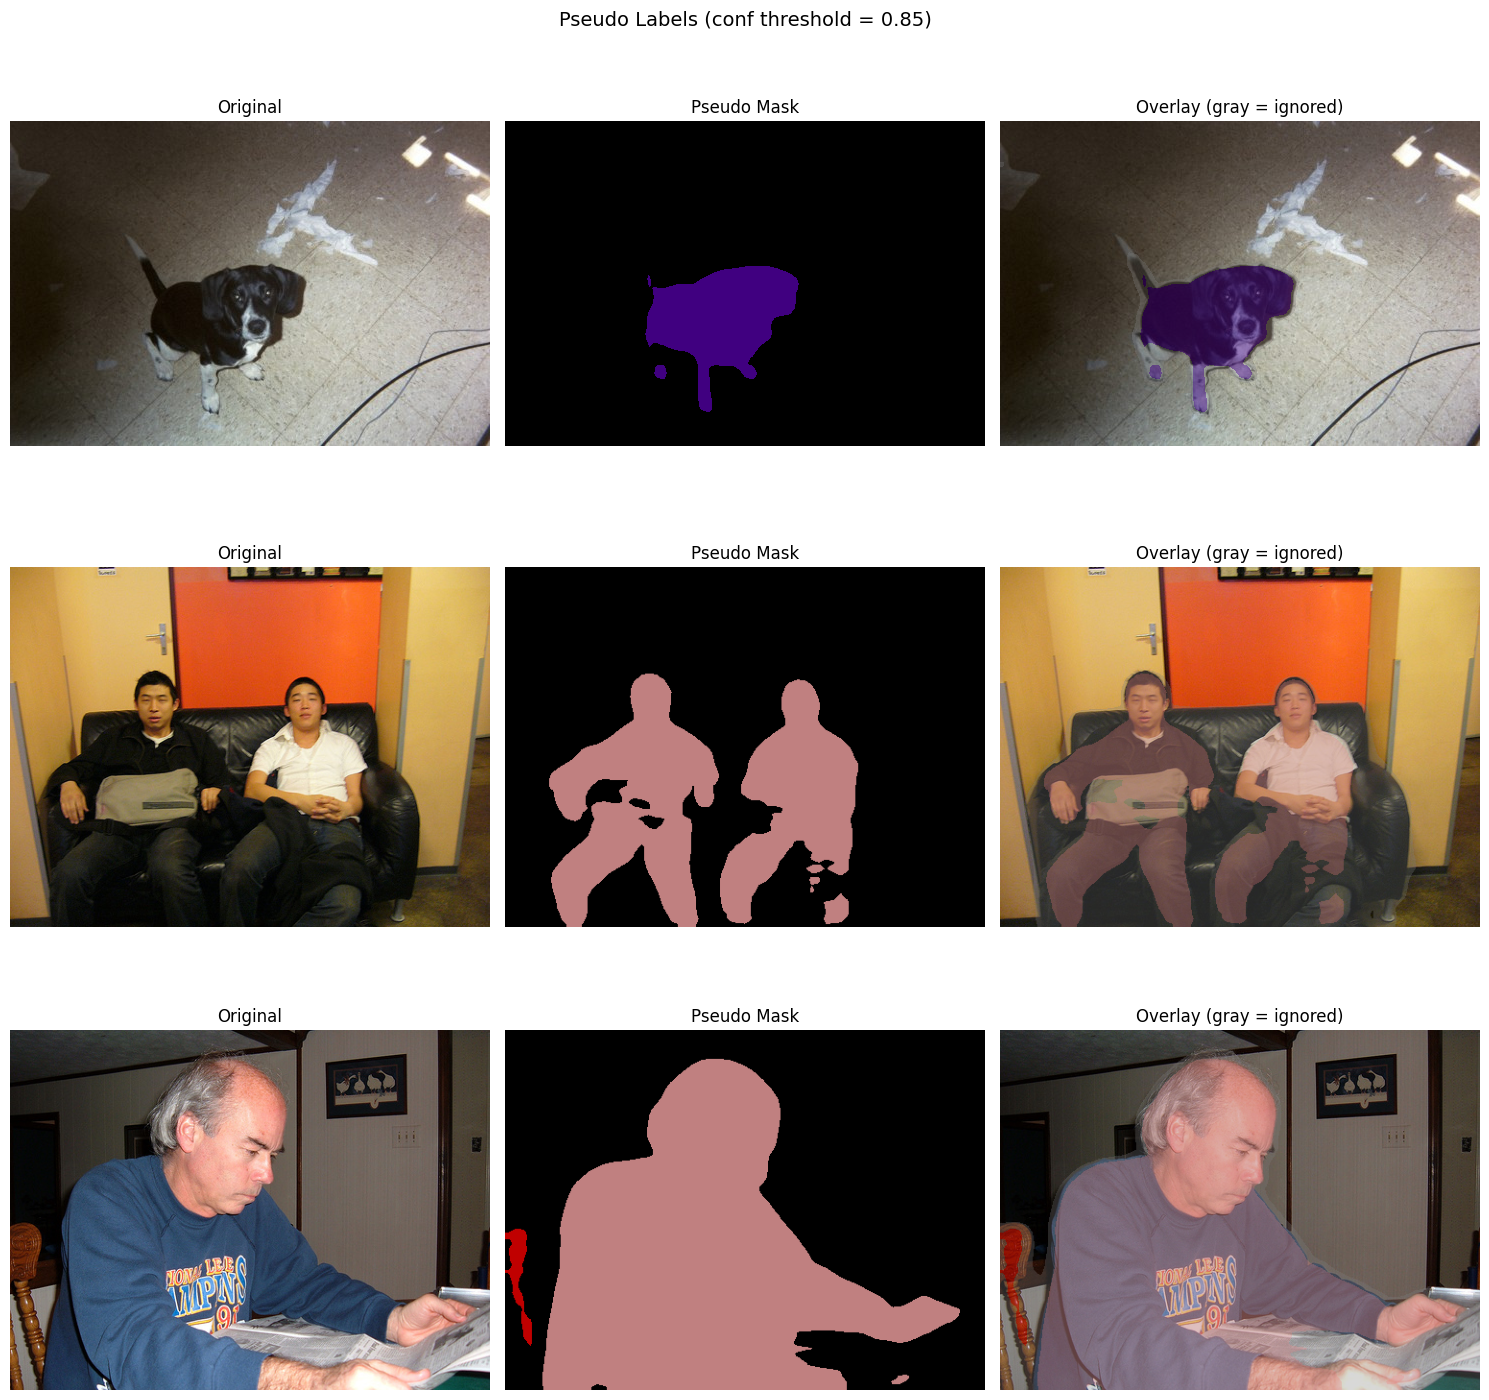

In [34]:
pseudo_files = os.listdir(PSEUDO_MASK_DIR)
print(f"Saved pseudo masks: {len(pseudo_files)}")

fig, axes = plt.subplots(3, 3, figsize=(15, 15))

for idx, ax_row in enumerate(axes):
    fname = pseudo_files[idx]
    img = np.array(Image.open(os.path.join(IMAGE_ROOT, fname.replace(".png", ".jpg"))).convert("RGB"))
    mask = np.array(Image.open(os.path.join(PSEUDO_MASK_DIR, fname)))

    color_mask = np.zeros((*mask.shape, 3), dtype=np.uint8)
    for cls_id, color in enumerate(VOC_COLORMAP):
        if cls_id < len(VOC_COLORMAP):
            color_mask[mask == cls_id] = color

    overlay = img.copy()
    valid = (mask > 0) & (mask != 255)
    overlay[valid] = (0.5 * img[valid] + 0.5 * color_mask[valid]).astype(np.uint8)
    overlay[mask == 255] = (0.7 * img[mask == 255] + 0.3 * np.array([128, 128, 128])).astype(np.uint8)

    ax_row[0].imshow(img)
    ax_row[0].set_title("Original")
    ax_row[0].axis("off")

    ax_row[1].imshow(color_mask)
    ax_row[1].set_title("Pseudo Mask")
    ax_row[1].axis("off")

    ax_row[2].imshow(overlay)
    ax_row[2].set_title("Overlay (gray = ignored)")
    ax_row[2].axis("off")

plt.suptitle(f"Pseudo Labels (conf threshold = {CONFIDENCE_THRESHOLD})", fontsize=14)
plt.tight_layout()
plt.show()

## Retrain with pseudo labels

In [35]:
pseudo_files = os.listdir(PSEUDO_MASK_DIR)
pseudo_fnames = [f.replace(".png", ".jpg") for f in pseudo_files]

df_pseudo = pd.DataFrame({
    "filename": pseudo_fnames,
    "subset": "pseudo",
})

df_pseudo["object_name"] = [[] for _ in range(len(df_pseudo))]

df_combined = pd.concat([
    df_trainval[df_trainval["subset"] == "train"][["filename", "subset", "object_name"]],
    df_pseudo
], ignore_index=True)

print(f"Original train: {len(df_trainval[df_trainval['subset']=='train'])}")
print(f"Pseudo labeled: {len(df_pseudo)}")
print(f"Combined train: {len(df_combined)}")

Original train: 1464
Pseudo labeled: 13646
Combined train: 15110


### Dataset

In [36]:
class CombinedSegDataset(torch.utils.data.Dataset):
    def __init__(self, df, img_dir, real_mask_dir, pseudo_mask_dir, transform=None):
        self.df = df
        self.img_dir = img_dir
        self.real_mask_dir = real_mask_dir
        self.pseudo_mask_dir = pseudo_mask_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = np.array(Image.open(os.path.join(self.img_dir, row["filename"])).convert("RGB"))

        mask_fname = row["filename"].replace(".jpg", ".png")
        if row["subset"] == "pseudo":
            mask = np.array(Image.open(os.path.join(self.pseudo_mask_dir, mask_fname)))
        else:
            mask = np.array(Image.open(os.path.join(self.real_mask_dir, mask_fname)))

        if self.transform:
            transformed = self.transform(image=img, mask=mask)
            img = transformed["image"]
            mask = transformed["mask"]

        mask = mask.long()
        label = torch.zeros(20)
        for cls_id in torch.unique(mask):
            cls_id = cls_id.item()
            if 0 < cls_id < 21:
                label[cls_id - 1] = 1

        return img, mask, label

### U-Net Retrain

In [37]:
del teacher_model
torch.cuda.empty_cache()

In [38]:
import gc

for var_name in ['teacher_model', 'lit_dino_model', 'test_model', 'pseudo_loader', 'pseudo_dataset']:
    if var_name in dir():
        exec(f'del {var_name}')

gc.collect()
torch.cuda.empty_cache()

print(f"GPU memory allocated: {torch.cuda.memory_allocated()/1024**3:.2f} GB")
print(f"GPU memory reserved: {torch.cuda.memory_reserved()/1024**3:.2f} GB")

GPU memory allocated: 0.23 GB
GPU memory reserved: 0.67 GB


In [ ]:
DEVICE = "cuda"
N_EPOCHS = 4
NAME = "smp_unet_resnet34_pseudo"

train_tfms_semi = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.ShiftScaleRotate(scale_limit=0.5, rotate_limit=0, shift_limit=0.1, p=1, border_mode=0),
    A.PadIfNeeded(min_height=320, min_width=320, p=1),
    A.RandomCrop(height=320, width=320, p=1),
    A.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
    ToTensorV2()
])

val_tfms_semi = A.Compose([
    A.PadIfNeeded(min_height=512, min_width=512, p=1),
    A.CenterCrop(height=512, width=512, p=1),
    A.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
    ToTensorV2()
])

combined_train_ds = CombinedSegDataset(
    df=df_combined,
    img_dir=IMAGE_ROOT,
    real_mask_dir=SEG_ROOT,
    pseudo_mask_dir=PSEUDO_MASK_DIR,
    transform=train_tfms_semi,
)

val_ds = SegmentDataset(
    df=df_trainval[df_trainval["subset"] == "val"].reset_index(drop=True),
    img_dir=IMAGE_ROOT,
    mask_dir=SEG_ROOT,
    transform=val_tfms_semi,
)

combined_train_loader = torch.utils.data.DataLoader(combined_train_ds, batch_size=16, num_workers=12, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_ds, batch_size=16, num_workers=12, shuffle=False)

try:
    lit_semi_model = LitSegmentationModule(
        model_class=smp.Unet,
        model_kwargs={
            "encoder_name": "resnet34",
            "encoder_weights": "imagenet",
            "in_channels": 3,
            "classes": 21,
        },
        criterion_inits={
            "DiceLoss": smp.losses.DiceLoss,
            "CE": torch.nn.CrossEntropyLoss,
        },
        criterion_kwargs={
            "DiceLoss": {"mode": "multiclass", "ignore_index": 255},
            "CE": {"ignore_index": 255},
        },
        criterion_coefs={"DiceLoss": 1.0, "CE": 1.0},
        n_classes=21,
        initial_lr=1e-3,
        final_lr=1e-5,
        T_max=N_EPOCHS,
        ignore_index=255,
    )

    trainer = pl.Trainer(
        max_epochs=N_EPOCHS,
        accelerator="gpu",
        precision="16-mixed",
        callbacks=[
            pl.callbacks.ModelCheckpoint(monitor="val_loss", mode="min", save_top_k=1, filename=NAME + "-{epoch}-{val_loss:.4f}"),
            pl.callbacks.EarlyStopping(monitor="val_loss", patience=5, mode="min"),
        ],
        logger=pl.loggers.CSVLogger("logs", name=NAME),
    )
    lit_semi_model._log_validation_example = lambda *args, **kwargs: None
    trainer.fit(lit_semi_model, combined_train_loader, val_loader)

except Exception as e:
    print(f"Error: {e}")
    raise e

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 12 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torchmetrics/utilities/prints.py:43: UserWarning: DiceScore metric currently defaults to `average=micro`, but will change to`average=macro` in the v1.9 release. If you've explicitly set this parameter, you can ignore this warning.
  warnings.warn(*args,

┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model         │ Unet             │ 24.4 M │ train │     0 │
│ 1 │ criterion     │ ModuleDict       │      0 │ train │     0 │
│ 2 │ train_metrics │ MetricCollection │      0 │ train │     0 │
│ 3 │ val_metrics   │ MetricCollection │      0 │ train │     0 │
└───┴───────────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 24.4 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 24.4 M                                                                                               
Total estimated model params size (MB): 97                                                                         
Modules in train mode: 197                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will 
create 12 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller 
than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader 
running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()

## Eval

In [ ]:
semi_metrics = {
    "val_loss": 1.000,
    "val_DiceScore": 0.322,
    "val_MeanIoU": 0.097,
    "train_DiceScore": 0.404,
    "train_MeanIoU": 0.144,
    "epochs": 4,
    "train_size": len(df_combined),
}
print("Semi-supervised (pseudo labels) results:")
for k, v in semi_metrics.items():
    print(f"  {k}: {v}")

In [ ]:
lit_semi_model.eval()
lit_semi_model.to(DEVICE)

hard_samples = []

with torch.no_grad():
    for batch_idx, (imgs, masks, labels) in enumerate(tqdm(val_loader, desc="Analyzing hard samples")):
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        logits = lit_semi_model(imgs)
        preds = logits.argmax(dim=1)

        for i in range(imgs.shape[0]):
            mask_i = masks[i]
            pred_i = preds[i]
            valid = (mask_i != 255)
            if valid.sum() == 0:
                continue
            intersection = ((pred_i == mask_i) & valid).sum().float()
            union = valid.sum().float()
            pixel_acc = (intersection / union).item()
            hard_samples.append({
                "batch_idx": batch_idx,
                "sample_idx": i,
                "pixel_acc": pixel_acc,
            })

hard_samples = sorted(hard_samples, key=lambda x: x["pixel_acc"])
print(f"\nWorst 10 samples (pixel accuracy):")
for s in hard_samples[:10]:
    print(f"  batch={s['batch_idx']}, sample={s['sample_idx']}, acc={s['pixel_acc']:.3f}")

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(15, 15))

for row_idx in range(3):
    s = hard_samples[row_idx]
    batch = list(val_loader)[s["batch_idx"]]
    img = batch[0][s["sample_idx"]]
    mask = batch[1][s["sample_idx"]]

    with torch.no_grad():
        pred = lit_semi_model(img.unsqueeze(0).to(DEVICE)).argmax(dim=1).squeeze().cpu()

    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img_vis = (img * std + mean).permute(1, 2, 0).numpy().clip(0, 1)

    axes[row_idx][0].imshow(img_vis)
    axes[row_idx][0].set_title(f"Image (acc={hard_samples[row_idx]['pixel_acc']:.3f})")
    axes[row_idx][0].axis("off")

    axes[row_idx][1].imshow(mask.numpy(), cmap="tab20", vmin=0, vmax=20)
    axes[row_idx][1].set_title("Ground Truth")
    axes[row_idx][1].axis("off")

    axes[row_idx][2].imshow(pred.numpy(), cmap="tab20", vmin=0, vmax=20)
    axes[row_idx][2].set_title("Prediction")
    axes[row_idx][2].axis("off")

plt.suptitle("Hardest Samples — Semi-supervised Model", fontsize=14)
plt.tight_layout()
plt.show()

## Interactive Segmentation

In [43]:
!pip install -q segment-anything
!wget -q https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth -O /kaggle/working/sam_vit_b.pth

In [44]:
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator

sam = sam_model_registry["vit_b"](checkpoint="/kaggle/working/sam_vit_b.pth").to(DEVICE)
sam.eval()

mask_generator = SamAutomaticMaskGenerator(
    model=sam,
    points_per_side=8,         
    pred_iou_thresh=0.86,
    stability_score_thresh=0.92,
    min_mask_region_area=1000,  
)
print("SAM loaded")

SAM loaded


In [45]:
N_INTERACTIVE = 200
SAM_MASK_DIR = "/kaggle/working/sam_masks"
os.makedirs(SAM_MASK_DIR, exist_ok=True)

lit_semi_model.eval().to(DEVICE)

interactive_tfms = A.Compose([
    A.PadIfNeeded(min_height=320, min_width=320, p=1),
    A.CenterCrop(height=320, width=320, p=1),
    A.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
    ToTensorV2()
])

sam_stats = {"total": 0, "saved": 0, "avg_masks_per_img": []}

for idx in tqdm(range(N_INTERACTIVE), desc="SAM interactive labels"):
    fname = df_unlabeled.iloc[idx]["filename"]
    img_path = os.path.join(IMAGE_ROOT, fname)
    img_np = np.array(Image.open(img_path).convert("RGB"))

    sam_masks = mask_generator.generate(img_np)
    sam_stats["avg_masks_per_img"].append(len(sam_masks))

    if len(sam_masks) == 0:
        continue

    transformed = interactive_tfms(image=img_np)
    img_tensor = transformed["image"].unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        class_preds = lit_semi_model(img_tensor).argmax(dim=1).squeeze().cpu().numpy()

    class_preds_full = cv2.resize(
        class_preds.astype(np.uint8),
        (img_np.shape[1], img_np.shape[0]),
        interpolation=cv2.INTER_NEAREST,
    )

    final_mask = np.zeros(img_np.shape[:2], dtype=np.uint8)
    for m in sorted(sam_masks, key=lambda x: x["area"]):  
        seg = m["segmentation"]
        pixels_in_mask = class_preds_full[seg]
        fg_pixels = pixels_in_mask[pixels_in_mask > 0]
        if len(fg_pixels) > 0:
            cls = np.bincount(fg_pixels).argmax()
        else:
            cls = 0  
        final_mask[seg] = cls

    sam_stats["total"] += 1
    sam_stats["saved"] += 1
    save_path = os.path.join(SAM_MASK_DIR, fname.replace(".jpg", ".png"))
    Image.fromarray(final_mask).save(save_path)

print(f"\nProcessed: {sam_stats['total']}")
print(f"Saved: {sam_stats['saved']}")
print(f"Avg masks per image: {np.mean(sam_stats['avg_masks_per_img']):.1f}")

SAM interactive labels: 100%|██████████| 200/200 [03:06<00:00,  1.07it/s]


Processed: 200
Saved: 200
Avg masks per image: 17.0


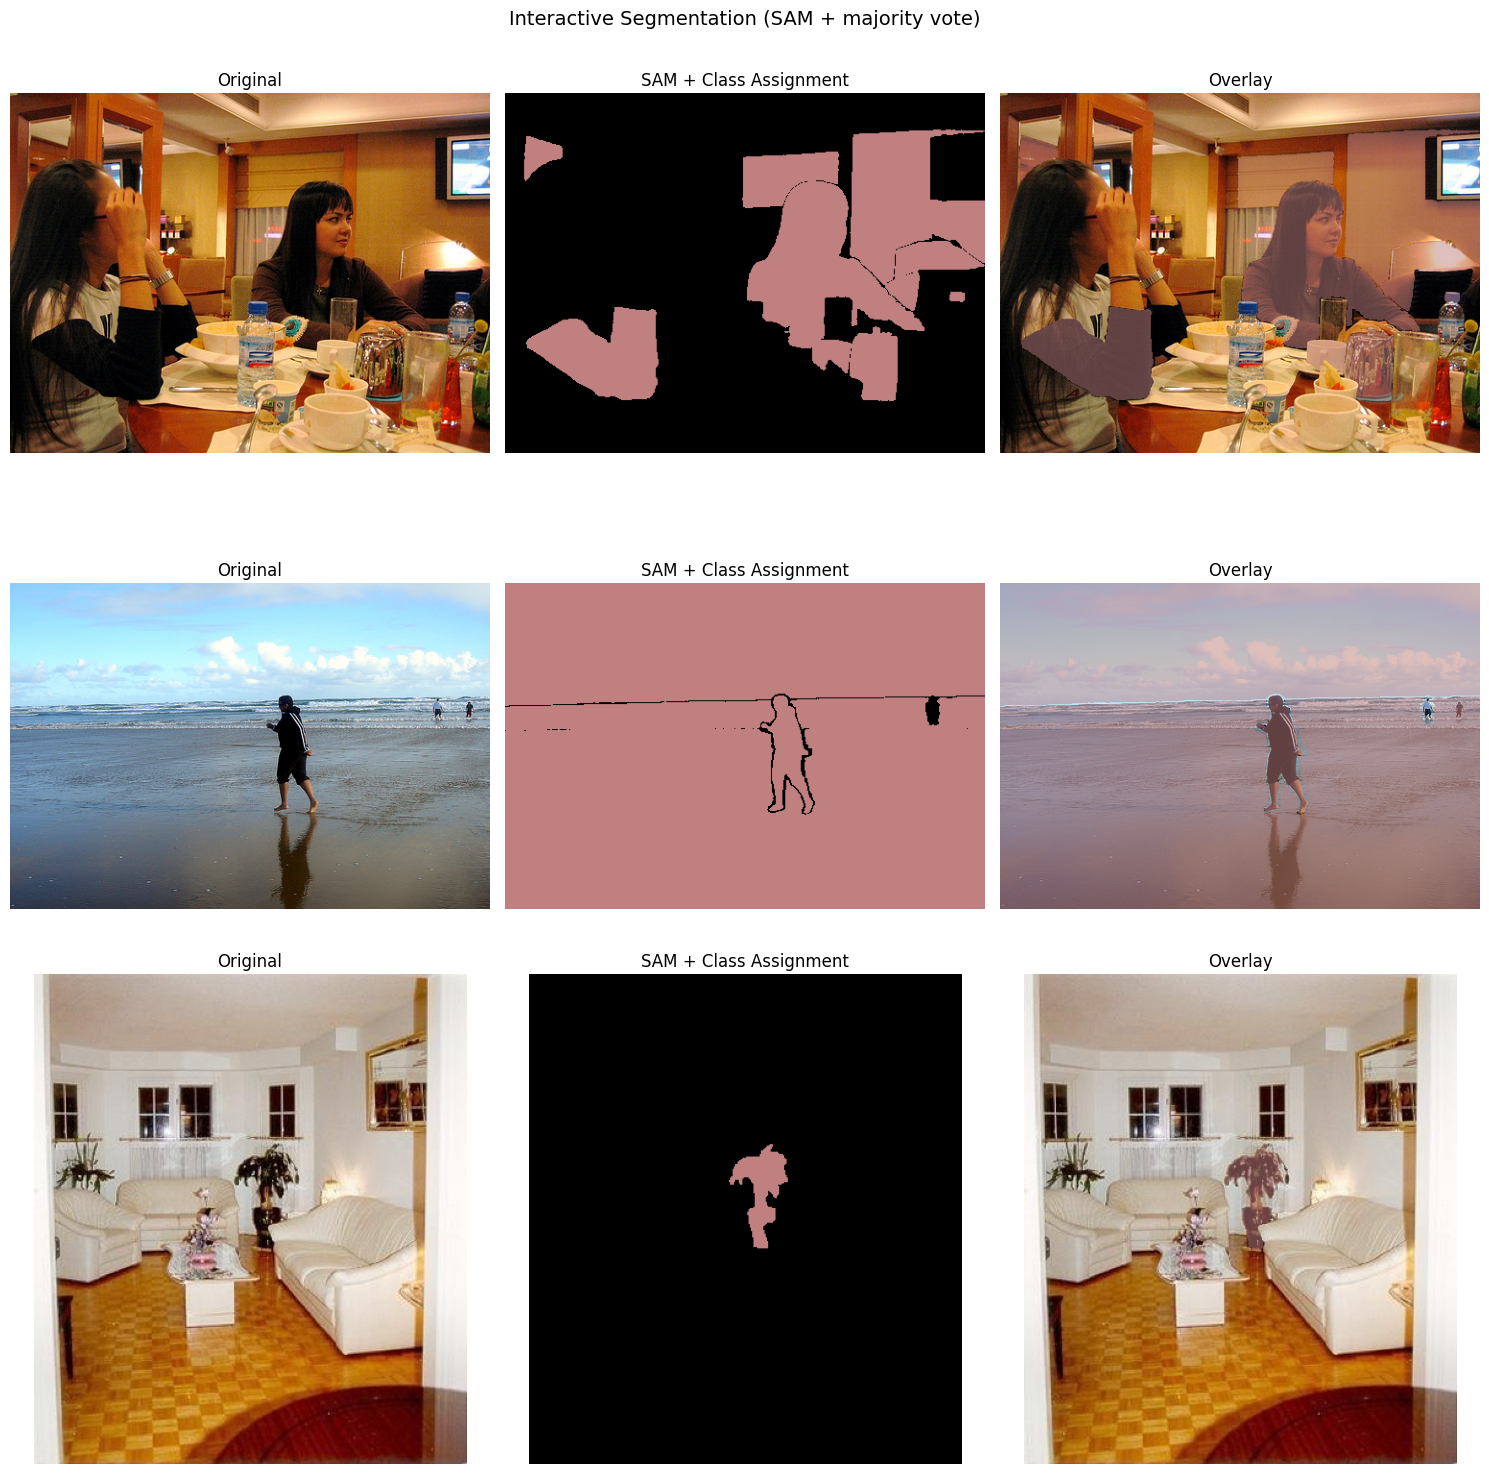

In [47]:
sam_files = os.listdir(SAM_MASK_DIR)
fig, axes = plt.subplots(3, 3, figsize=(15, 15))

for idx, ax_row in enumerate(axes):
    fname = sam_files[idx]
    img = np.array(Image.open(os.path.join(IMAGE_ROOT, fname.replace(".png", ".jpg"))).convert("RGB"))
    mask = np.array(Image.open(os.path.join(SAM_MASK_DIR, fname)))

    color_mask = np.zeros((*mask.shape, 3), dtype=np.uint8)
    for cls_id in range(len(VOC_COLORMAP)):
        color_mask[mask == cls_id] = VOC_COLORMAP[cls_id]

    overlay = img.copy()
    valid = mask > 0
    overlay[valid] = (0.5 * img[valid] + 0.5 * color_mask[valid]).astype(np.uint8)

    ax_row[0].imshow(img)
    ax_row[0].set_title("Original")
    ax_row[0].axis("off")

    ax_row[1].imshow(color_mask)
    ax_row[1].set_title("SAM + Class Assignment")
    ax_row[1].axis("off")

    ax_row[2].imshow(overlay)
    ax_row[2].set_title("Overlay")
    ax_row[2].axis("off")

plt.suptitle("Interactive Segmentation (SAM + majority vote)", fontsize=14)
plt.tight_layout()
plt.show()

# Ablation Stady

In [48]:
ablation = pd.DataFrame([
    {"Model": "SMP U-Net (ResNet34)", "Approach": "Supervised baseline", 
     "Train Size": 1464, "val_MeanIoU": 0.1109, "val_DiceScore": 0.328, "Epochs": 15},
    
    {"Model": "DINOv2 + SegHead", "Approach": "Self-supervised features", 
     "Train Size": 1464, "val_MeanIoU": 0.5771, "val_DiceScore": 0.833, "Epochs": 15},
    
    {"Model": "U-Net (ResNet34)", "Approach": "Semi-sup (pseudo labels)", 
     "Train Size": f"1464 + {len(df_combined)-1464}", "val_MeanIoU": 0.097, "val_DiceScore": 0.322, "Epochs": 4},
])

print("=" * 90)
print("ABLATION STUDY — Semi-supervised & Interactive Segmentation")
print("=" * 90)
print(ablation.to_string(index=False))


ABLATION STUDY — Semi-supervised & Interactive Segmentation
               Model                 Approach   Train Size  val_MeanIoU  val_DiceScore  Epochs
SMP U-Net (ResNet34)      Supervised baseline         1464       0.1109          0.328      15
    DINOv2 + SegHead Self-supervised features         1464       0.5771          0.833      15
    U-Net (ResNet34) Semi-sup (pseudo labels) 1464 + 13646       0.0970          0.322       4
